In [1]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2

# Set seed for reproducibility
SEED = 28
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
tf.__version__

'2.16.1'

In [ ]:
model = tf.keras.models.load_model('sardine_model.keras')

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,012,805 (34.38 MB)

 Trainable params: 657,921 (2.51 MB)

 Non-trainable params: 7,039,040 (26.85 MB)

 Optimizer params: 1,315,844 (5.02 MB)

In [5]:
input_shape = (224,224,3)
target_size = list(input_shape)[:2]
batch_size = 32

print('Input Shape', input_shape)
print('Target Size', target_size)
print('Batch Size', batch_size)

Input Shape (224, 224, 3)
Target Size [224, 224]
Batch Size 32


In [6]:
def preprocess(image):
    image = cv2.resize(image,target_size)
    image = tf.keras.applications.densenet.preprocess_input(image)
    return image

In [7]:
datagen = ImageDataGenerator(
    preprocessing_function = preprocess, 
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess,
)

In [8]:
train = datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/train_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = True,
    seed=SEED
)

val = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/val_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed=SEED
)

test = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/test_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

unseen = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/unseen_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

app_test = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/app_testing_sardine_segmented_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

Found 11978 images belonging to 2 classes.
Found 3742 images belonging to 2 classes.
Found 3423 images belonging to 2 classes.
Found 101 images belonging to 2 classes.
Found 2093 images belonging to 2 classes.


In [19]:
def count_class_images(data, dataset_name='Train'):
    class_counts = {class_name: 0 for class_name in data.class_indices.keys()}
    for label in data.classes:
        class_name = list(data.class_indices.keys())[label]
        class_counts[class_name] += 1
    print(f'{dataset_name} Dataset: {class_counts}')

In [20]:
count_class_images(train, dataset_name='Train')
count_class_images(val, dataset_name='Validation')
count_class_images(test, dataset_name='Test')
count_class_images(unseen, dataset_name='Unseen')
count_class_images(app_test, dataset_name='App Test')

Train Dataset: {'Bad': 6010, 'Good': 5968}
Validation Dataset: {'Bad': 1873, 'Good': 1869}
Test Dataset: {'Bad': 1711, 'Good': 1712}
Unseen Dataset: {'Bad': 51, 'Good': 50}
App Test Dataset: {'Bad': 670, 'Good': 1423}


In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,   
    patience=3,           
    min_lr=1e-7,          
    verbose=1,
    mode = 'min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', 
                               restore_best_weights=True, verbose=1, min_delta=0.01)

checkpoint_filepath = '/kaggle/working/checkpoint.keras'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
#     save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

In [10]:
callbacks = [early_stopping, reduce_lr_callback, model_checkpoint_callback]

In [11]:
model.layers[0].name

'densenet121'

In [12]:
from tensorflow.keras.optimizers import Adam

model.layers[0].trainable = True

model.compile(optimizer=Adam(learning_rate = 1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,696,961 (29.36 MB)

 Trainable params: 7,611,777 (29.04 MB)

 Non-trainable params: 85,184 (332.75 KB)

In [13]:
history = model.fit(train, validation_data=val, epochs=20, batch_size=batch_size, callbacks=callbacks)

Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1729314024.944466      98 service.cc:145] XLA service 0x782f00004220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729314024.944518      98 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1729314024.944524      98 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1729314119.351357      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/375 ━━━━━━━━━━━━━━━━━━━━ 3:43 1s/step - accuracy: 0.6779 - loss: 0.6283

I0000 00:00:1729314377.346456      98 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_slice_fusion_3', 8 bytes spill stores, 8 bytes spill loads



375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6908 - loss: 0.6097
Epoch 1: val_loss improved from inf to 0.57919, saving model to /kaggle/working/checkpoint.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 729s 2s/step - accuracy: 0.6908 - loss: 0.6096 - val_accuracy: 0.7143 - val_loss: 0.5792 - learning_rate: 1.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.7460 - loss: 0.5318
Epoch 2: val_loss improved from 0.57919 to 0.54061, saving model to /kaggle/working/checkpoint.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 307s 805ms/step - accuracy: 0.7460 - loss: 0.5318 - val_accuracy: 0.7373 - val_loss: 0.5406 - learning_rate: 1.0000e-05
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.7706 - loss: 0.4992
Epoch 3: val_loss improved from 0.54061 to 0.52900, saving model to /kaggle/working/checkpoint.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 299s 785ms/step - accuracy: 0.7706 - loss: 0.4992 - val_accuracy: 0.7483 - val_loss: 0.5290 - learning_rate: 1.0000e-05
Epoch 4

In [14]:
def plot_accuracy_loss(history, label):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Two subplots: one for accuracy, one for loss

    # Plot accuracy on the left
    ax1.plot(history.history['accuracy'], label=f'Train Accuracy {label}')
    ax1.plot(history.history['val_accuracy'], label=f'Val Accuracy {label}')
    ax1.set_title(f'Accuracy {label}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot loss on the right
    ax2.plot(history.history['loss'], label=f'Train Loss {label}')
    ax2.plot(history.history['val_loss'], label=f'Val Loss {label}')
    ax2.set_title(f'Loss {label}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

<Figure size 1200x600 with 0 Axes>

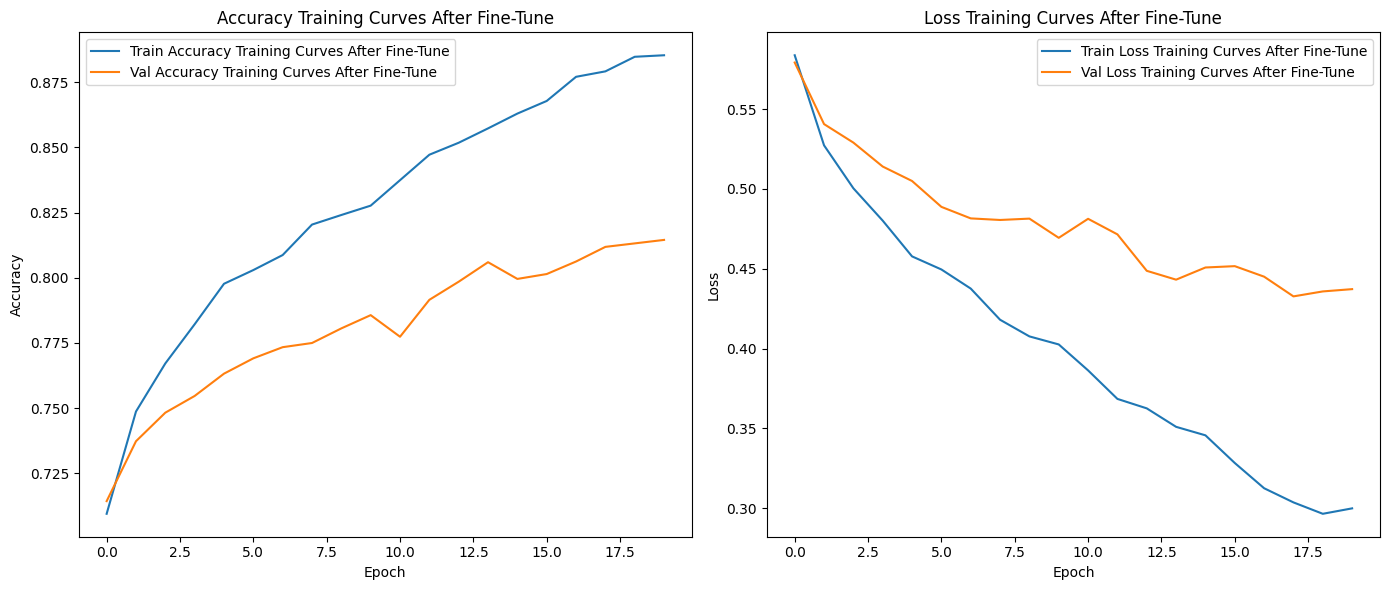

In [15]:
# Plot accuracy and loss for the model without custom callback
plt.figure(figsize=(12, 6))
plot_accuracy_loss(history, label='Training Curves After Fine-Tune')

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=test_generator.class_indices.keys()))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=test_generator.class_indices.keys())

117/117 ━━━━━━━━━━━━━━━━━━━━ 50s 356ms/step
Classification Report:

              precision    recall  f1-score   support

         Bad       0.86      0.75      0.80      1873
        Good       0.78      0.87      0.82      1869

    accuracy                           0.81      3742
   macro avg       0.82      0.81      0.81      3742
weighted avg       0.82      0.81      0.81      3742

Confusion matrix, without normalization


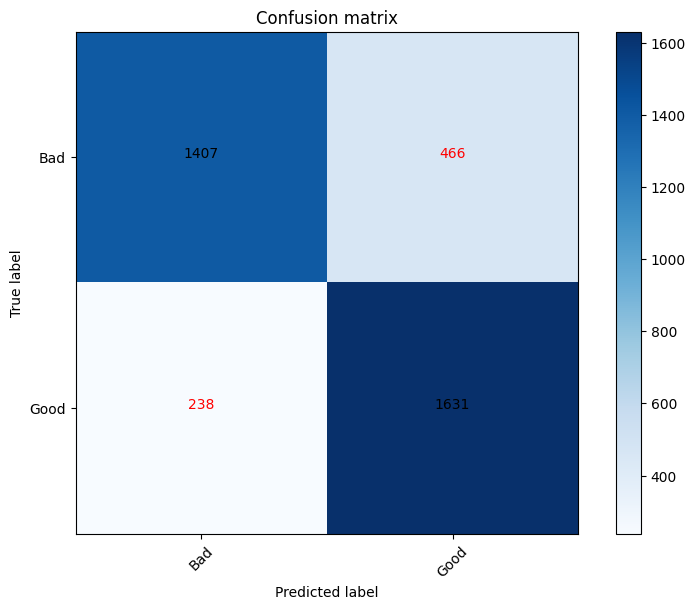

In [17]:
evaluate_binary_classification_model(model,val,0.5 )

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 782ms/step
Classification Report:

              precision    recall  f1-score   support

         Bad       0.86      0.78      0.82      1711
        Good       0.80      0.88      0.84      1712

    accuracy                           0.83      3423
   macro avg       0.83      0.83      0.83      3423
weighted avg       0.83      0.83      0.83      3423

Confusion matrix, without normalization


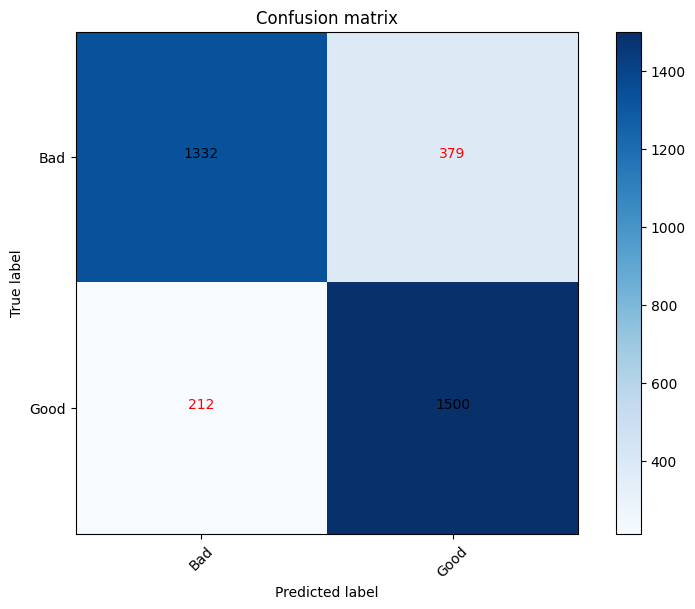

In [18]:
evaluate_binary_classification_model(model,test,0.5 )

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step  
Classification Report:

              precision    recall  f1-score   support

         Bad       0.93      0.78      0.85        51
        Good       0.81      0.94      0.87        50

    accuracy                           0.86       101
   macro avg       0.87      0.86      0.86       101
weighted avg       0.87      0.86      0.86       101

Confusion matrix, without normalization


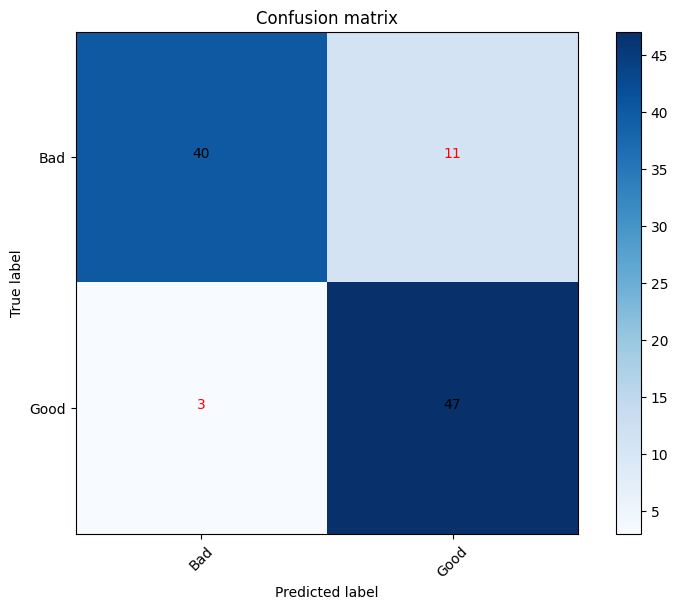

In [23]:
evaluate_binary_classification_model(model,unseen,0.5 )

 2/66 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step
Classification Report:

              precision    recall  f1-score   support

         Bad       0.71      0.66      0.68       670
        Good       0.84      0.88      0.86      1423

    accuracy                           0.81      2093
   macro avg       0.78      0.77      0.77      2093
weighted avg       0.80      0.81      0.80      2093

Confusion matrix, without normalization


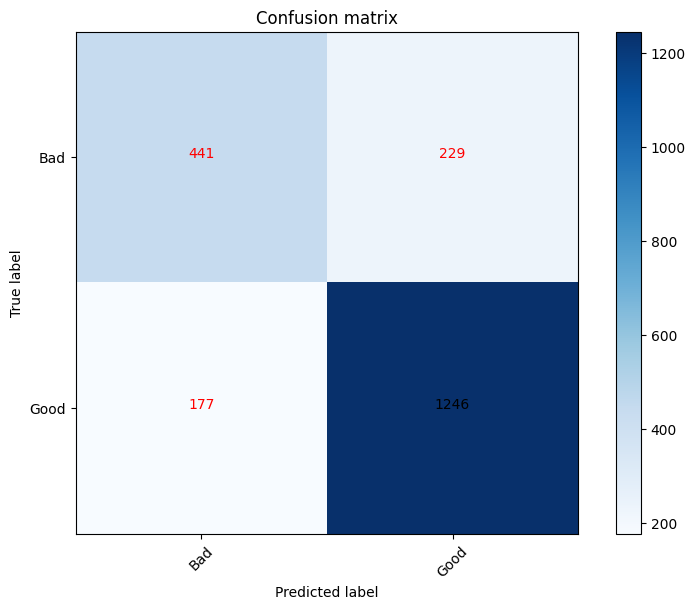

In [24]:
evaluate_binary_classification_model(model,app_test,0.5 )

In [19]:
model.save('sardine_final_model_20epochs_k_gpu.keras')

In [20]:
model.export('sardine_model_20epochs_k_gpu', format='tf')

Saved artifact at 'sardine_model_20epochs_k_gpu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132145753906112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754063264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754065552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145753910688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145753913152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754071008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754072768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754070832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754071712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132145754075232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

In [22]:
! zip -rq sardine_model_20epochs_k_gpu.zip '/kaggle/working/sardine_model_20epochs_k_gpu'